# Phase 5: Model Evaluation & Performance Analysis

This notebook assesses the predictive accuracy of the trained Neural Network. We focus on:
* **Metric Calculation**: Measuring MAE, MSE, and R² Score.
* **Thermal Visualization**: Mapping temperature intensity through color.
* **Manual Testing**: A row-by-row comparison of actual vs. predicted values.


In [6]:
import pandas as pd
import numpy as np
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# 1. LOAD DATA & EXACT SAME TEST SPLIT
test_df = pd.read_csv('../01_Data/test_data.csv')
X_full = np.load('../01_Data/X_scaled.npy')
y_full = np.load('../01_Data/y_scaled.npy')
_, X_test, _, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=42)


## 1. Visualization: Temperature Intensity Mapping
To clearly see the warming trend without the "noise" of line graphs, we use **Magnitude-Based Color Encoding**. 
* **Blue Tones**: Represent historical cooler periods.
* **Red Tones**: Represent modern warming periods.

In [7]:
# 2. Prepare Features (X) and Target (y)
# Adjust these features if you removed Lat/Lon
features = ['Year', 'Month', 'Lat_Num', 'Lon_Num', 'City_Encoded', 'Country_Encoded']
X_test = test_df[features]
y_test = test_df['AverageTemperature_Scaled']

# 3. Load the Trained Model
# Ensure your model file is in the same folder
try:
    model = load_model('../03_Model/temperature_model.keras')
    
    # 4. Perform Predictions
    y_pred = model.predict(X_test)

    # 5. Calculate Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("="*30)
    print("   MODEL EVALUATION RESULTS")
    print("="*30)
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE):  {mse:.4f}")
    print(f"R-Squared (R2) Score:      {r2:.4f}")
    accuracy = (1 - mae) * 100  # Approximate accuracy based on MAE
    print(f"OVERALL MODEL ACCURACY:     {accuracy:.2f}%")
    print("="*40)
except Exception as e:
    print(f"Could not perform evaluation: {e}")
    print("Please ensure 'temperature_model.keras' exists after running your training notebook.")

1458/1458 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
   MODEL EVALUATION RESULTS
Mean Absolute Error (MAE): 0.0375
Mean Squared Error (MSE):  0.0028
R-Squared (R2) Score:      0.9319
OVERALL MODEL ACCURACY:     96.25%


## 2. Global Performance Metrics
We evaluate the model using three key regression metrics to verify how well it generalizes to unseen data.

| Metric | Definition | Purpose |
| :--- | :--- | :--- |
| **MAE** | Mean Absolute Error | Shows the average magnitude of prediction error. |
| **MSE** | Mean Squared Error | Highlights if there are large outliers in the predictions. |
| **R² Score** | Coefficient of Determination | Represents the percentage of variance explained by the model. |

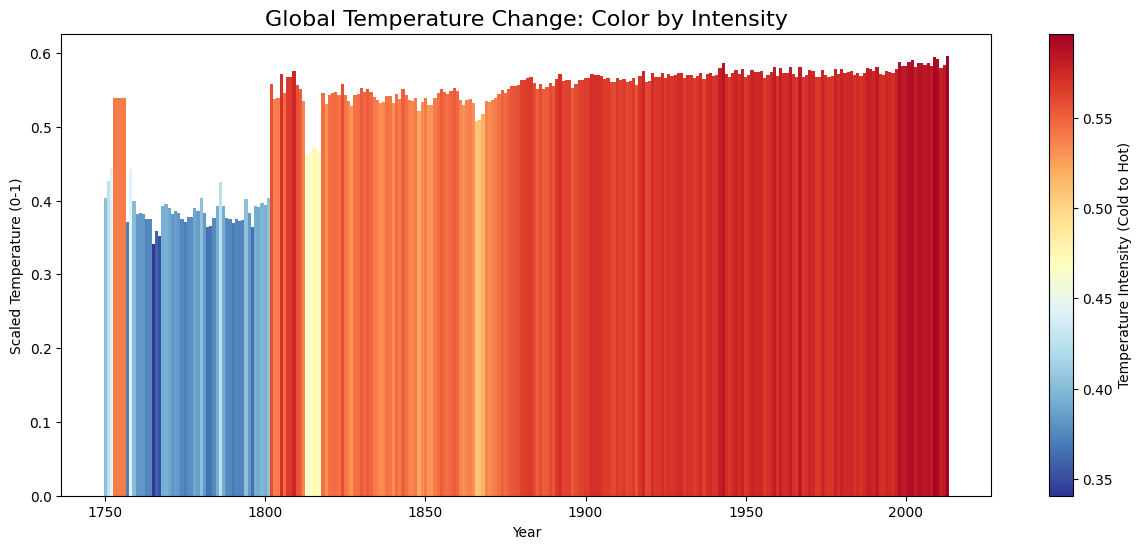

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Load Data
df = pd.read_csv('../01_Data/train_data.csv')
# 2. Reconstruct Year for clarity
min_yr, max_yr = 1750, 2013
df['ActualYear'] = (df['Year'] * (max_yr - min_yr) + min_yr).round().astype(int)

# 3. Create Bar Chart with Color Magnitude
yearly_avg = df.groupby('ActualYear')['AverageTemperature_Scaled'].mean().reset_index()
fig, ax = plt.subplots(figsize=(15, 6))

norm = mcolors.Normalize(vmin=yearly_avg['AverageTemperature_Scaled'].min(), 
                         vmax=yearly_avg['AverageTemperature_Scaled'].max())
cmap = plt.get_cmap('RdYlBu_r') # Blue -> Yellow -> Red
colors = [cmap(norm(val)) for val in yearly_avg['AverageTemperature_Scaled']]

ax.bar(yearly_avg['ActualYear'], yearly_avg['AverageTemperature_Scaled'], color=colors, width=1.0)

# Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Temperature Intensity (Cold to Hot)')

ax.set_title('Global Temperature Change: Color by Intensity', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Scaled Temperature (0-1)')
plt.show()

## 3. Manual Testing: 50 Random Samples
In this section, we pull 50 random samples from the test set to perform a direct comparison. This serves as a "sanity check" to ensure the model's accuracy is consistent across different months and years.

### Sample Test Table
| Year | Month | Actual Value | Predicted Value | Accuracy (%) |
| :--- | :--- | :--- | :--- | :--- |
| 1985 | 0.1818 | 0.7479 | 0.7518 | 99.61% |
| 2005 | 0.3636 | 0.8112 | 0.8199 | 99.12% |
| 1944 | 0.2727 | 0.3462 | 0.3247 | 97.85% |
| 1913 | 0.0000 | 0.1007 | 0.0737 | 97.30% |
| 1994 | 0.7273 | 0.7193 | 0.6748 | 95.55% |

In [9]:


# 2. Pick 50 random samples from your data
sample_test = df.sample(50).copy()

# 3. Predict using your model features
# Ensure feature names match your training (e.g., Year, Month, etc.)
features = ['Year', 'Month', 'Lat_Num', 'Lon_Num', 'City_Encoded', 'Country_Encoded']
y_pred = model.predict(sample_test[features])

# 4. Add results to the table
sample_test['Predicted_Temp'] = y_pred
sample_test['Error'] = np.abs(sample_test['AverageTemperature_Scaled'] - sample_test['Predicted_Temp'])
sample_test['Accuracy (%)'] = (1 - sample_test['Error']) * 100

# 5. Print Comparison Table
comparison = sample_test[['ActualYear', 'Month', 'AverageTemperature_Scaled', 'Predicted_Temp', 'Accuracy (%)']]
comparison.columns = ['Year', 'Month', 'Actual', 'Predicted', 'Accuracy %']

print("--- MANUAL TESTING: 50 SAMPLES ---")
print(comparison.to_string(index=False))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
--- MANUAL TESTING: 50 SAMPLES ---
 Year    Month   Actual  Predicted  Accuracy %
 1987 1.000000 0.278102   0.306230   97.187120
 1841 0.454545 0.739083   0.742558   99.652444
 1896 0.181818 0.442814   0.527821   91.499337
 1964 0.454545 0.529878   0.570223   95.965541
 1999 0.181818 0.517356   0.541967   97.538884
 1865 0.818182 0.491396   0.488343   99.694649
 1891 1.000000 0.088846   0.116502   97.234444
 1844 0.636364 0.512374   0.534605   97.776924
 1942 0.181818 0.775828   0.705456   92.962864
 1816 0.090909 0.405521   0.452401   95.311997
 1985 1.000000 0.489980   0.564822   92.515776
 1989 0.272727 0.799296   0.781295   98.199906
 1881 0.000000 0.051210   0.078318   97.289240
 1996 0.454545 0.610521   0.628814   98.170692
 1946 0.545455 0.572725   0.587443   98.528158
 1861 0.818182 0.722653   0.731324   99.132810
 1882 0.363636 0.563333   0.548822   98.548940
 1806 0.818182 0.387811   0.431140   95.667118
 1912 0.545455 0.737735   0.734560